In [23]:
import os
from dotenv import load_dotenv

# Charge les variables cachées du fichier .env
load_dotenv() 

# La clé est maintenant chargée en mémoire sans être visible dans le code !
print("Clé API chargée depuis le .env !")

Clé API chargée depuis le .env !


In [24]:
# === CONFIGURATION DU PROJET ===
# TODO : renseigner les noms de vos deux classes (en snake_case, sans espace)
CLASS_A = "hot_dog"
CLASS_B = "not_hot_dog"
# TODO : chemin racine où les images brutes seront extraites
DATA_ROOT = "./data"

In [25]:
!kaggle datasets download -d dansbecker/hot-dog-not-hot-dog -p ./raw_data

# Dézippage local
import zipfile

os.makedirs("./raw_data", exist_ok=True)
with zipfile.ZipFile("./raw_data/hot-dog-not-hot-dog.zip", 'r') as zip_ref:
    zip_ref.extractall("./raw_data")
print("Dataset dézippé avec succès")

Dataset URL: https://www.kaggle.com/datasets/dansbecker/hot-dog-not-hot-dog
License(s): other




  0%|          | 0.00/89.3M [00:00<?, ?B/s]
  1%|          | 1.00M/89.3M [00:00<00:45, 2.03MB/s]
  3%|▎         | 3.00M/89.3M [00:00<00:15, 5.78MB/s]
  8%|▊         | 7.00M/89.3M [00:00<00:06, 13.7MB/s]
 13%|█▎        | 12.0M/89.3M [00:00<00:03, 23.0MB/s]
 19%|█▉        | 17.0M/89.3M [00:00<00:02, 30.1MB/s]
 25%|██▍       | 22.0M/89.3M [00:01<00:02, 35.3MB/s]
 30%|███       | 27.0M/89.3M [00:01<00:01, 39.3MB/s]
 36%|███▌      | 32.0M/89.3M [00:01<00:01, 42.3MB/s]
 41%|████▏     | 37.0M/89.3M [00:01<00:01, 44.2MB/s]
 47%|████▋     | 42.0M/89.3M [00:01<00:01, 45.8MB/s]
 53%|█████▎    | 47.0M/89.3M [00:01<00:00, 45.9MB/s]
 59%|█████▉    | 53.0M/89.3M [00:01<00:00, 47.3MB/s]
 65%|██████▍   | 58.0M/89.3M [00:01<00:00, 48.4MB/s]
 71%|███████   | 63.0M/89.3M [00:01<00:00, 48.2MB/s]
 76%|███████▌  | 68.0M/89.3M [00:02<00:00, 48.6MB/s]
 83%|████████▎ | 74.0M/89.3M [00:02<00:00, 48.6MB/s]
 88%|████████▊ | 79.0M/89.3M [00:02<00:00, 49.2MB/s]
 95%|█████████▌| 85.0M/89.3M [00:02<00:00, 48.7MB/s]
1

Dataset dézippé avec succès


In [26]:
import os, shutil, random
import glob

# TODO 1 : lister les fichiers bruts pour CLASS_A et CLASS_B
# (adapter le chemin selon la structure livrée par Kaggle)
files_a = glob.glob("./raw_data/**/hot_dog/*.jpg", recursive=True)
files_b = glob.glob("./raw_data/**/not_hot_dog/*.jpg", recursive=True)

# TODO 2 : créer les dossiers train/CLASS_A, train/CLASS_B, val/CLASS_A, val/CLASS_B
# avec os.makedirs(..., exist_ok=True)
for split in ['train', 'val']:
    for cls in [CLASS_A, CLASS_B]:
        os.makedirs(os.path.join(DATA_ROOT, split, cls), exist_ok=True)

# TODO 3 : mélanger chaque liste (random.shuffle) avec seed=42 pour la reproductibilité
random.seed(42)
random.shuffle(files_a)

random.seed(42)
random.shuffle(files_b)

# TODO 4 : split 80% train / 20% val pour chaque classe et copier avec shutil.copy
def split_and_copy(files, class_name):
    split_idx = int(len(files) * 0.8)
    
    # 80% pour l'entraînement
    for f in files[:split_idx]:
        shutil.copy(f, os.path.join(DATA_ROOT, 'train', class_name))
        
    # 20% pour la validation
    for f in files[split_idx:]:
        shutil.copy(f, os.path.join(DATA_ROOT, 'val', class_name))

# Lancement de la répartition
split_and_copy(files_a, CLASS_A)
split_and_copy(files_b, CLASS_B)

# Vérification : ce bloc doit tourner sans modification
for split in ['train', 'val']:
    for cls in [CLASS_A, CLASS_B]:
        path = os.path.join(DATA_ROOT, split, cls)
        print(f"{path} : {len(os.listdir(path))} images")

./data\train\hot_dog : 482 images
./data\train\not_hot_dog : 482 images
./data\val\hot_dog : 183 images
./data\val\not_hot_dog : 183 images


Shape hot_dog 1 : (512, 512, 3)
Shape hot_dog 2 : (512, 512, 3)
Shape hot_dog 3 : (512, 512, 3)
Shape not_hot_dog 1 : (382, 512, 3)
Shape not_hot_dog 2 : (384, 512, 3)
Shape not_hot_dog 3 : (384, 512, 3)


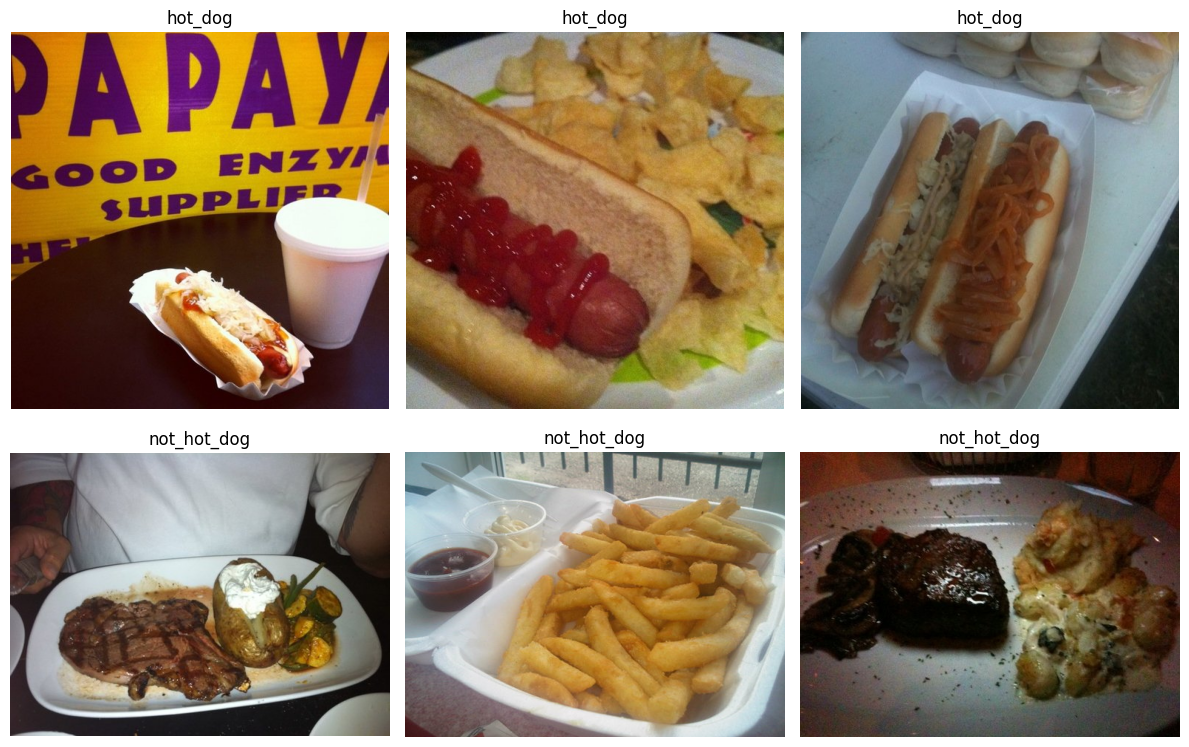

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# TODO : afficher 3 images de CLASS_A et 3 images de CLASS_B côte à côte.
# Structure : plt.subplot(2, 3, i+1), plt.imshow(), plt.title(CLASS_A ou CLASS_B)
# Vérifier que les shapes se terminent par 3 (RGB) ou 1 (niveaux de gris).
plt.figure(figsize=(12, 8))

# Chemins vers images d'entraînement triées
train_dir_a = os.path.join(DATA_ROOT, 'train', CLASS_A)
train_dir_b = os.path.join(DATA_ROOT, 'train', CLASS_B)

# Liste des 3 premières images de chaque classe
images_a = os.listdir(train_dir_a)[:3]
images_b = os.listdir(train_dir_b)[:3]

# Affichage des 3 images de la classe A (hot_dog) sur la première ligne
for i, img_name in enumerate(images_a):
    img_path = os.path.join(train_dir_a, img_name)
    img = mpimg.imread(img_path)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(CLASS_A)
    plt.axis('off')
    print(f"Shape {CLASS_A} {i+1} : {img.shape}")

# Affichage des 3 images de la classe B (not_hot_dog) sur la deuxième ligne
for i, img_name in enumerate(images_b):
    img_path = os.path.join(train_dir_b, img_name)
    img = mpimg.imread(img_path)
    
    plt.subplot(2, 3, i + 4) 
    plt.imshow(img)
    plt.title(CLASS_B)
    plt.axis('off')
    print(f"Shape {CLASS_B} {i+1} : {img.shape}")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
# TODO : choisir la taille de redimensionnement et la taille de batch.
# Conseils : IMG_SIZE entre 64x64 et 160x160 selon la RAM Colab disponible.
# BATCH_SIZE entre 16 et 64 (32 est un bon défaut).
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

# TODO : compléter les paramètres de image_dataset_from_directory pour train_ds.
# Paramètres à renseigner : image_size, batch_size, label_mode, shuffle, seed.
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "train"),
    # TODO : tous les paramètres
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=42
)
# TODO : même chose pour val_ds (shuffle=False pour la reproductibilité).
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "val"),
    # TODO : tous les paramètres
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False, 
    seed=42
)

# TODO : appliquer Rescaling(1./255) sur train_ds et val_ds avec .map().
# normalization_layer = tf.keras.layers.Rescaling(1./255)
normalization_layer = tf.keras.layers.Rescaling(1./255)

# TODO : appliquer .cache().prefetch(buffer_size=AUTOTUNE) sur train_ds.
# et .cache().prefetch(buffer_size=AUTOTUNE) sur val_ds.
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# TODO : afficher la shape du premier batch (images et labels).
# Indice : next(iter(train_ds)) retourne un tuple (images, labels).
# Shape attendue images : (BATCH_SIZE, IMG_SIZE[0], IMG_SIZE[1], 3)
# Shape attendue labels : (BATCH_SIZE, 1)
# Valeurs attendues : entre 0.0 et 1.0 après Rescaling
image_batch, label_batch = next(iter(train_ds))

print("\n--- vérif ---")
print(f"Shape des images attendue : ({BATCH_SIZE}, {IMG_SIZE[0]}, {IMG_SIZE[1]}, 3)")
print(f"Shape des images obtenue  : {image_batch.shape}")
print(f"Shape des labels attendue : ({BATCH_SIZE}, 1)")
print(f"Shape des labels obtenue  : {label_batch.shape}")

min_val = tf.reduce_min(image_batch)
max_val = tf.reduce_max(image_batch)
print(f"Valeurs des pixels : de {min_val:.1f} à {max_val:.1f} (attendu: 0.0 à 1.0)")

Found 964 files belonging to 2 classes.
Found 366 files belonging to 2 classes.

--- VÉRIFICATION DU BATCH ---
Shape des images attendue : (32, 160, 160, 3)
Shape des images obtenue  : (32, 160, 160, 3)
Shape des labels attendue : (32, 1)
Shape des labels obtenue  : (32, 1)
Valeurs des pixels : de 0.0 à 1.0 (attendu: 0.0 à 1.0)


In [35]:
from tensorflow.keras import layers, models

def build_cnn_scratch(input_shape):
    """
    CNN from scratch pour la classification binaire.
    Architecture délibérément simple : on veut voir l'overfitting, pas l'éviter.
    input_shape : tuple (H, W, C) correspondant à votre IMG_SIZE + nombre de canaux
    Retourne : un model Sequential non compilé
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # TODO : bloc 1 - Conv2D(32, (3,3), activation='relu', padding='same',input_shape=input_shape)
        # suivi MaxPooling2D((2,2))
        # Shape en sortie : (H/2, W/2, 32) - calculer avec votre IMG_SIZE
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # TODO : bloc 2 - Conv2D(64, (3,3)) + MaxPooling2D((2,2))
        # Shape en sortie : (H/4, W/4, 64) - calculer avant d'exécuter
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # TODO : bloc 3 - Conv2D(128, (3,3)) + MaxPooling2D((2,2))
        # Shape en sortie : (H/8, W/8, 128) - calculer avant d'exécuter
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # TODO : Flatten()
        # Shape en sortie : (H/8 * W/8 * 128,) - calculer le nombre total d'éléments
        layers.Flatten(),

        # TODO : Dense(128, activation='relu')
        layers.Dense(128, activation='relu'),

        layers.Dense(1, activation='sigmoid')
        ])
    return model

model_scratch = build_cnn_scratch(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
model_scratch.summary()

# TODO : compiler avec optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
model_scratch.compile(
    optimizer='adam',
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
import datetime, time
# Callback TensorBoard : un log par run, avec un timestamp pour ne pas écraser les précédents.
log_dir = "logs/scratch/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# TODO : créer le callback TensorBoard qui log dans log_dir.
# tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# TODO : créer un callback EarlyStopping qui surveille 'val_loss',
# avec patience=5 et restore_best_weights=True.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

print("Démarrage de l'entraînement")
start = time.time()

# TODO : lancer model_scratch.fit(train_ds, epochs=20, validation_data=val_ds,
# callbacks=[tensorboard_callback, early_stopping])
history_scratch = model_scratch.fit(
    train_ds, 
    epochs=20, 
    validation_data=val_ds,
    callbacks=[tensorboard_callback, early_stopping]
)

training_time_scratch = time.time() - start
print(f"Temps d'entraînement : {training_time_scratch:.0f}s")
print(f"val_accuracy finale : {max(history_scratch.history['val_accuracy']):.3f}")

Démarrage de l'entraînement)


c:\Users\Batyste\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - accuracy: 0.5083 - loss: 0.7098 - val_accuracy: 0.5464 - val_loss: 0.6908
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.5239 - loss: 0.6921 - val_accuracy: 0.5082 - val_loss: 0.6889
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.5602 - loss: 0.6875 - val_accuracy: 0.5792 - val_loss: 0.6690
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.5902 - loss: 0.6691 - val_accuracy: 0.5847 - val_loss: 0.6503
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.5861 - loss: 0.6603 - val_accuracy: 0.6475 - val_loss: 0.6302
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.6743 - loss: 0.6291 - val_accuracy: 0.6721 - val_loss: 0.5959
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.7147 - loss: 0.5888 - val_accuracy: 0.7104 - val_loss: 0.5603
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.7490 - loss: 0.5197 - val_accuracy: 0.

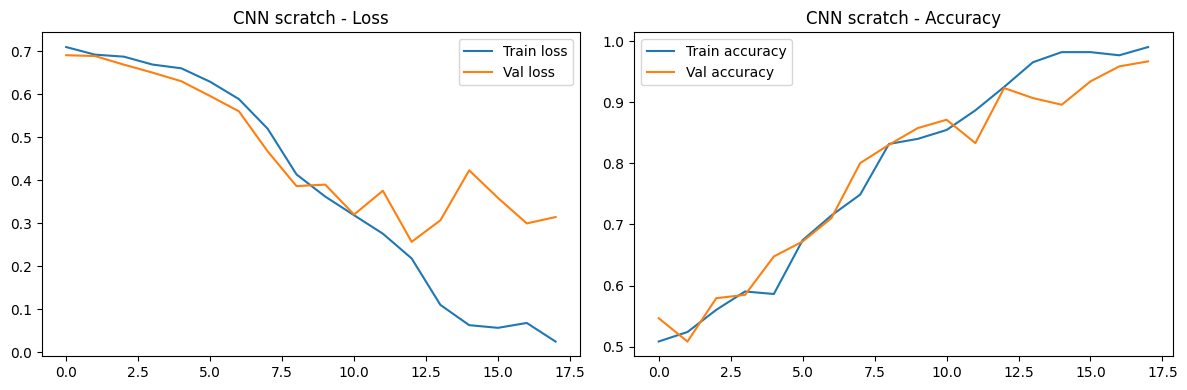

In [39]:
import matplotlib.pyplot as plt

def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], label='Train loss')
    ax1.plot(history.history['val_loss'], label='Val loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"curves_{title.lower().replace(' ', '_')}.png", dpi=100)
    plt.show()

plot_history(history_scratch, "CNN scratch")

In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs/scratch

#ça na pas marché donc j'ai lancé tensorboard --logdir logs dans le terminal et je suis allé sur http://localhost:6006/#timeseries

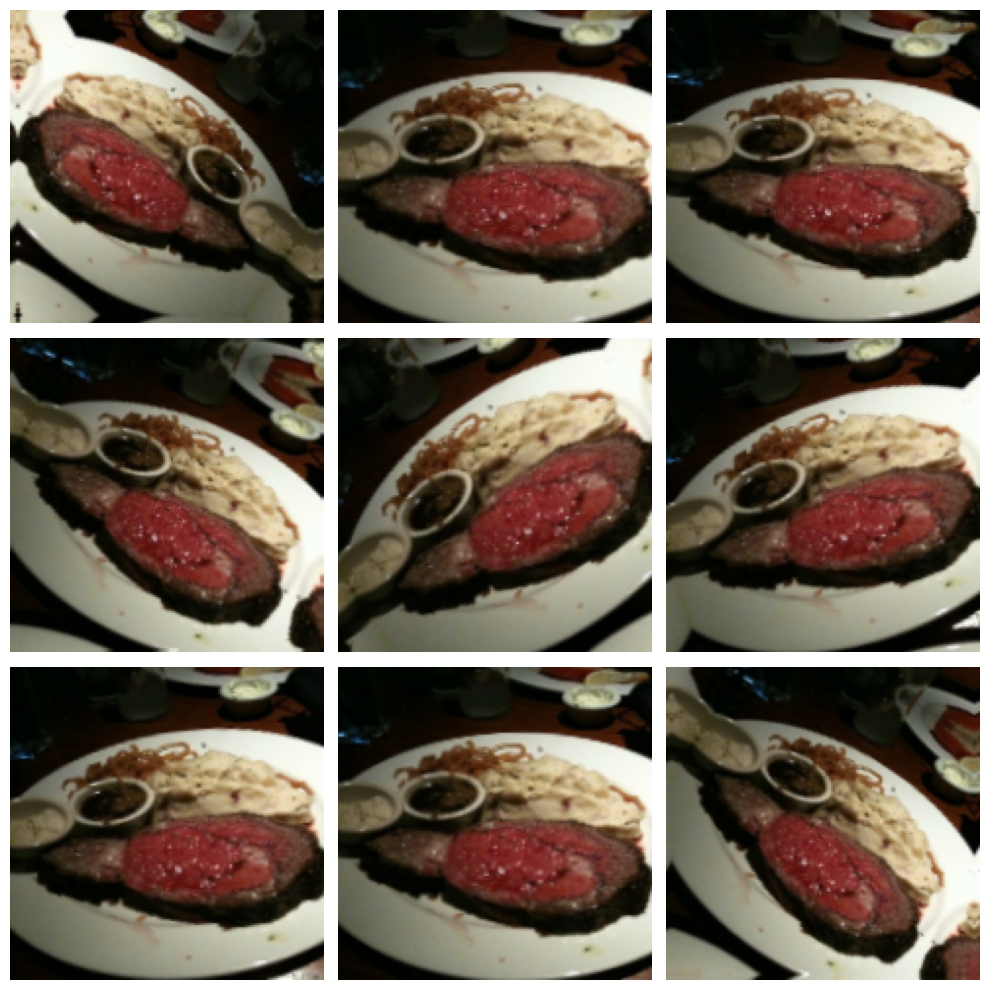

In [41]:
from tensorflow.keras import layers, models

# Ces couches sont actives uniquement en mode training (model.fit) et
# passives en mode inférence (model.predict, model.evaluate).
# Conséquence : la val_accuracy est calculée sur les images ORIGINALES. C'est voulu.
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    # TODO : ajouter RandomRotation avec un facteur adapté à votre domaine.
    # Indice : factor entre 0.05 (légère rotation, ~18°) et 0.15 (~54°).
    layers.RandomRotation(0.1),
    # Pour des radiographies, une rotation forte peut changer le diagnostic : choisir <0.1.
    # TODO : ajouter RandomZoom avec un facteur de votre choix.
    # Indice : factor entre 0.05 et 0.15.
    layers.RandomZoom(0.1),
], name="data_augmentation")

# TODO : récupérer une image d'exemple depuis train_ds (next(iter(train_ds))[0][0])
# et afficher une grille 3x3 de versions augmentées de cette même image.
sample_image = next(iter(train_ds))[0][0]
plt.figure(figsize=(10, 10))
# Structure :
# for i in range(9):
for i in range(9):
    # augmented = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
    augmented_image = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
    
    plt.subplot(3, 3, i + 1)
    # plt.subplot(3, 3, i+1) ; plt.imshow(augmented[0]) ; plt.axis('off')
    plt.imshow(augmented_image[0].numpy())
    plt.axis('off')

# Sauvegarder avec plt.savefig("augmentation_grid.png", dpi=100)
plt.tight_layout()
plt.savefig("augmentation_grid.png", dpi=100)
plt.show()

Démarrage de l'entraînement du modèle augmenté
Epoch 1/20


c:\Users\Batyste\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - accuracy: 0.4782 - loss: 0.7608 - val_accuracy: 0.5000 - val_loss: 0.6974
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.5104 - loss: 0.6957 - val_accuracy: 0.5000 - val_loss: 0.7006
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.5197 - loss: 0.6949 - val_accuracy: 0.5027 - val_loss: 0.6933
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.5270 - loss: 0.6907 - val_accuracy: 0.5847 - val_loss: 0.6695
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.5550 - loss: 0.6811 - val_accuracy: 0.5410 - val_loss: 0.6957
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.5519 - loss: 0.6823 - val_accuracy: 0.5410 - val_loss: 0.6818
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.5965 - loss: 0.6679 - val_accuracy: 0.6530 - val_loss: 0.6463
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.6110 - loss: 0.6529 - val_accuracy: 0.6585 - val_

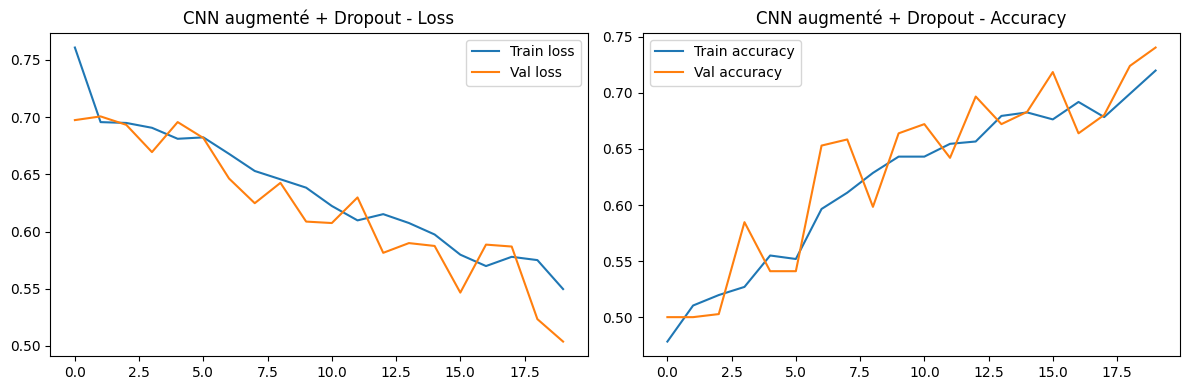

In [42]:
import time
import datetime
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_augmented(input_shape):
    """
    CNN avec data augmentation intégrée + Dropout.
    Même architecture de base que build_cnn_scratch, mais avec régularisation.
    input_shape : tuple (H, W, C)
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,

        # TODO : reprendre les 3 blocs Conv2D + MaxPooling de build_cnn_scratch.
        # Shape attendue identique à TP1, la data_augmentation ne change pas les shapes.
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # TODO : Flatten()
        layers.Flatten(),

        # TODO : Dropout(0.4)
        # Coupe 40% des connexions aléatoirement à chaque batch.
        # Placer APRES Flatten (pas entre les blocs Conv) : les feature maps spatiales
        # ne doivent pas être coupées, seulement les activations après aplatissement.
        layers.Dropout(0.4),

        # TODO : Dense(128, activation='relu')
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
        ])
    return model

model_augmented = build_cnn_augmented(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# TODO : compiler model_augmented (mêmes paramètres que TP1)
model_augmented.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# TODO : créer log_dir_aug, tensorboard_callback_aug, early_stopping_aug
# (même structure que phase 1.4, log dans "logs/augmented/...")
log_dir_aug = "logs/augmented/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_aug = tf.keras.callbacks.TensorBoard(log_dir=log_dir_aug, histogram_freq=1)

early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# TODO : lancer model_augmented.fit(...) avec les mêmes hyperparamètres que TP1
# Stocker dans history_augmented, mesurer training_time_augmented
print("Démarrage de l'entraînement du modèle augmenté")

start = time.time()

history_augmented = model_augmented.fit(
    train_ds, 
    epochs=20, 
    validation_data=val_ds,
    callbacks=[tensorboard_callback_aug, early_stopping_aug]
)

training_time_augmented = time.time() - start

print(f"Temps d'entraînement : {training_time_augmented:.0f}s")
print(f"val_accuracy finale : {max(history_augmented.history['val_accuracy']):.3f}")

plot_history(history_augmented, "CNN augmenté + Dropout")

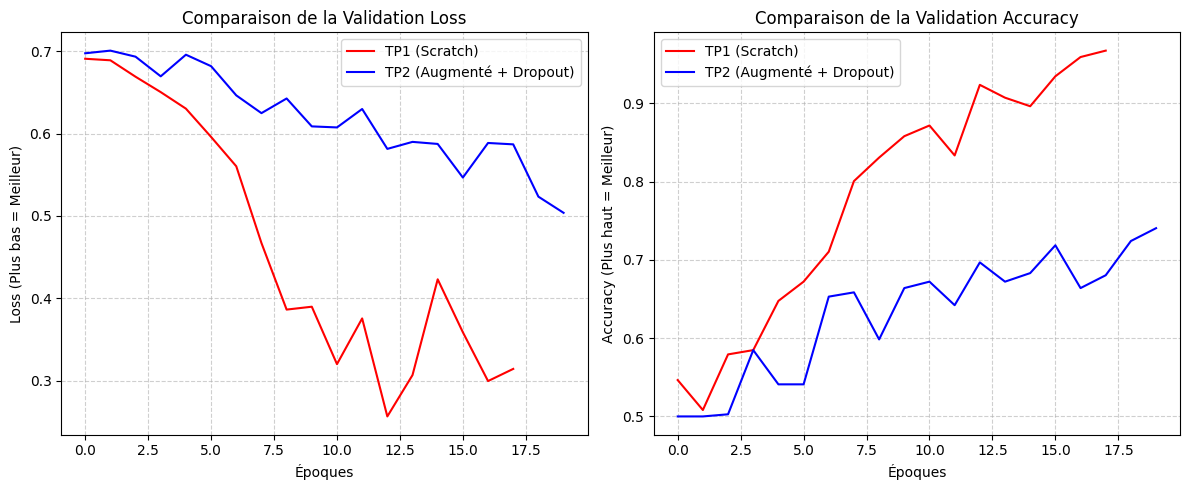

=== bilan perf ===
TP1 (Scratch)  | Max Val_Accuracy : 0.9672 | Temps : 68s | Paramètres : 6,647,105
TP2 (Augmenté) | Max Val_Accuracy : 0.7404 | Temps : 80s | Paramètres : 6,647,105


In [43]:
# TODO : tracer val_loss de history_scratch et history_augmented sur le même graphe (subplot 1/2).
plt.figure(figsize=(12, 5))
# TODO : tracer val_accuracy de history_scratch et history_augmented sur le même graphe (subplot 2/2).
# Structure attendue :
    # plt.subplot(1, 2, 1) pour la val_loss, plt.subplot(1, 2, 2) pour la val_accuracy
    # couleur rouge pour scratch, bleu pour augmenté
    # sauvegarder avec plt.savefig("comparison_tp1_tp2.png", dpi=100)
plt.subplot(1, 2, 1)
plt.plot(history_scratch.history['val_loss'], color='red', label='TP1 (Scratch)')
plt.plot(history_augmented.history['val_loss'], color='blue', label='TP2 (Augmenté + Dropout)')
plt.title('Comparaison de la Validation Loss')
plt.xlabel('Époques')
plt.ylabel('Loss (Plus bas = Meilleur)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history_scratch.history['val_accuracy'], color='red', label='TP1 (Scratch)')
plt.plot(history_augmented.history['val_accuracy'], color='blue', label='TP2 (Augmenté + Dropout)')
plt.title('Comparaison de la Validation Accuracy')
plt.xlabel('Époques')
plt.ylabel('Accuracy (Plus haut = Meilleur)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("comparison_tp1_tp2.png", dpi=100)
plt.show()
# TODO : afficher les métriques clés de comparaison.
# Clés à extraire :
# - val_accuracy max pour chaque modèle (max(history.history['val_accuracy']))
# - training_time pour chaque modèle
# - model.count_params() pour chaque modèle
print("=== bilan perf ===")
print(f"TP1 (Scratch)  | Max Val_Accuracy : {max(history_scratch.history['val_accuracy']):.4f} | Temps : {training_time_scratch:.0f}s | Paramètres : {model_scratch.count_params():,}")
print(f"TP2 (Augmenté) | Max Val_Accuracy : {max(history_augmented.history['val_accuracy']):.4f} | Temps : {training_time_augmented:.0f}s | Paramètres : {model_augmented.count_params():,}")

### Analyse TP1 vs TP2 : L'impact de la régularisation

Les résultats obtenus montrent une dynamique inattendue.
La convergence du TP2 (courbes bleues) est nettement plus lente et lisse que celle du TP1, ce qui s'explique par la complexité ajoutée : le processeur doit calculer les transformations à la volée (le temps d'entraînement passe de 68s à 80s) et le Dropout à 40% bride l'apprentissage par cœur. 
Cependant, le modèle "scratch" (TP1) surperforme ici avec 96.7% de `val_accuracy` contre seulement 74% pour le modèle augmenté. La forte régularisation du TP2 a rendu la tâche de classification trop complexe pour une architecture non pré-entraînée. Cela montre les limites d'un réseau initialisé de zéro : l'augmentation seule l'empêche de mémoriser, mais le réseau n'a pas la maturité (les filtres de base) pour extraire des caractéristiques complexes sur des images déformées.

In [44]:
# TODO : reconstruire train_ds_tl et val_ds_tl avec IMG_SIZE_TL = (160, 160).
# Même structure que phase 1.2 (image_dataset_from_directory, label_mode='binary', etc.).
IMG_SIZE_TL = (160, 160)
# TODO : créer train_ds_tl avec shuffle=True, seed=42
train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "train"),
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=42 # Toujours immuable !
)

# TODO : créer val_ds_tl avec shuffle=False, seed=42
val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "val"),
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,
    seed=42
)


Found 964 files belonging to 2 classes.
Found 366 files belonging to 2 classes.


In [45]:
# preprocess_input de MobileNetV2 normalise dans [-1, 1] (pas [0, 1]).
# Ne pas appliquer Rescaling(1./255) ici : preprocess_input le remplace.
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
AUTOTUNE = tf.data.AUTOTUNE

train_ds_tl = train_ds_tl.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
val_ds_tl = val_ds_tl.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(buffer_size=AUTOTUNE)

# TODO : appliquer preprocess_input sur train_ds_tl et val_ds_tl avec .map() + .prefetch(AUTOTUNE).
# Même structure que la normalisation en phase 1.2, juste avec preprocess_input à la place de Rescaling.
print("\nTéléchargement et chargement de MobileNetV2")
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False, 
    weights='imagenet'
)

# TODO : afficher le nombre de couches dans base_model (len(base_model.layers)).
print(f"Nombre de couches du modèle de base : {len(base_model.layers)}")
# TODO : afficher le nombre de paramètres totaux (base_model.count_params()).
print(f"Paramètres totaux du modèle de base : {base_model.count_params():,}")
# TODO : mettre base_model.trainable = False (geler toute la base)
base_model.trainable = False



Téléchargement et chargement de MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Nombre de couches du modèle de base : 154
Paramètres totaux du modèle de base : 2,257,984


In [46]:


# TODO : construire le modèle avec l'API fonctionnelle :
# inputs = tf.keras.Input(shape=(160, 160, 3))
inputs = tf.keras.Input(shape=(160, 160, 3))
# x = base_model(inputs, training=False) # training=False : BatchNorm reste en mode inférence
x = base_model(inputs, training=False)
# x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
# x = tf.keras.layers.Dense(128, activation='relu')(x)
# x = tf.keras.layers.Dropout(0.3)(x)
# outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
# model_tl = tf.keras.Model(inputs, outputs)
model_tl = tf.keras.Model(inputs, outputs)

# TODO : model_tl.summary()
model_tl.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Démarrage de l'entraînement de la tête seule...
Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.8683 - loss: 0.3357 - val_accuracy: 0.9426 - val_loss: 0.1576
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.9388 - loss: 0.1650 - val_accuracy: 0.9317 - val_loss: 0.1567
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9606 - loss: 0.1116 - val_accuracy: 0.9809 - val_loss: 0.0766
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.9803 - loss: 0.0754 - val_accuracy: 0.9891 - val_loss: 0.0587
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.9876 - loss: 0.0573 - val_accuracy: 0.9945 - val_loss: 0.0456
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9896 - loss: 0.0363 - val_accuracy: 0.9918 - val_loss: 0.0423
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9917 - loss: 0.0334 - val_accuracy: 0.9945 - val_loss: 0.0319
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - ac

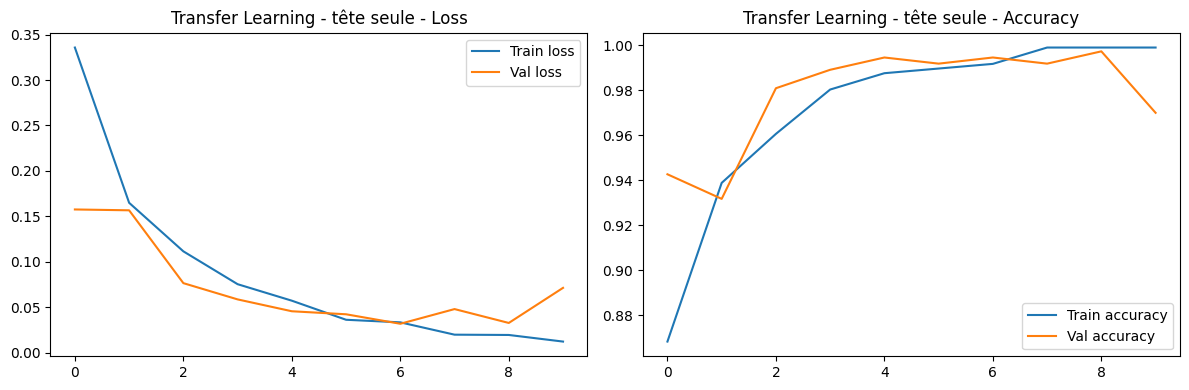

In [47]:
# TODO : compiler model_tl avec Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'].
# La base est gelée : on peut se permettre un lr élevé pour la tête.
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# TODO : créer log_dir_tl et tensorboard_callback_tl (log dans "logs/transfer/...")
log_dir_tl = "logs/transfer/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_tl = tf.keras.callbacks.TensorBoard(log_dir=log_dir_tl, histogram_freq=1)

# TODO : lancer model_tl.fit(train_ds_tl, epochs=10, validation_data=val_ds_tl,
# callbacks=[tensorboard_callback_tl])
print("Démarrage de model")
start = time.time()
# Stocker dans history_tl_head, mesurer training_time_head.
history_tl_head = model_tl.fit(
    train_ds_tl, 
    epochs=10, 
    validation_data=val_ds_tl,
    callbacks=[tensorboard_callback_tl]
)

training_time_head = time.time() - start

print(f"Temps d'entraînement (tête seule) : {training_time_head:.0f}s")
print(f"val_accuracy finale (tête seule) : {max(history_tl_head.history['val_accuracy']):.3f}")

plot_history(history_tl_head, "Transfer Learning - tête seule")
